# analysis for first presentation

In [1]:
# imports 
import pandas as pd
import ast

In [2]:
tk = pd.read_csv('tweede_kamer_data.csv', index_col=0)


In [13]:
tk.head()

,title,year,ai_related,company_hits,body,matched_keywords_all,type,n_company_hits
0,Investeren in Perspectief (Beleidsnota 2018),2018.0,yes,"{'Google': 1, 'Adyen': 1, 'X': 2}",Ook biedt de agenda kansen aan het bedrijfslev...,"['adyen', 'google', 'x', 'kunstmatige intellig...",beleidsnota,4
1,Nota Defensie Industrie Strategie,2018.0,yes,{},Nederland wil zelf aan militaire kennisontwikk...,"['ai', 'artificiële intelligentie', 'drones', ...",beleidsnota,0
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021.0,yes,{'Google': 1},Zo wordt in de vernieuwde strategie nu ook de ...,"['google', 'ai', 'algoritmes', 'artificiële in...",beleidsnota,1
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021.0,yes,{'X': 62},25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,"['x', 'ai']",beleidsnota,62
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021.0,yes,{'X': 2},Dit betreft de nota’s in de onderstaande tabel...,"['x', 'ai']",beleidsnota,2


In [17]:
# # make sure matched_keywords_all is list
# for idx, row in tk.iterrows():
#     if isinstance(row['matched_keywords_all'], str):
#         try:
#             tk.at[idx, 'matched_keywords_all'] = ast.literal_eval(row['matched_keywords_all'])
#         except (ValueError, SyntaxError):
#             tk.at[idx, 'matched_keywords_all'] = []

In [15]:
for idx, row in tk.iterrows():
    if isinstance(row['matched_keywords_all'], list):
        tk.at[idx, 'matched_keywords_all'] = list(dict.fromkeys(row['matched_keywords_all']))


In [16]:
tk['matched_keywords_all'].iloc[0]

"['adyen', 'google', 'x', 'kunstmatige intelligentie']"

In [23]:
tk['type'].value_counts()

type
plenair verslag    435
beleidsnota        347
vergaderstuk        66
Name: count, dtype: int64

In [7]:
tk.head()

,title,year,ai_related,company_hits,body,matched_keywords_all,type
0,Investeren in Perspectief (Beleidsnota 2018),2018.0,yes,"['adyen', 'google', 'x']",Ook biedt de agenda kansen aan het bedrijfslev...,"['adyen', 'google', 'x', 'kunstmatige intellig...",beleidsnota
1,Nota Defensie Industrie Strategie,2018.0,yes,[],Nederland wil zelf aan militaire kennisontwikk...,"['ai', 'artificiële intelligentie', 'drones', ...",beleidsnota
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021.0,yes,['google'],Zo wordt in de vernieuwde strategie nu ook de ...,"['google', 'ai', 'algoritmes', 'artificiële in...",beleidsnota
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021.0,yes,['x'],25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,"['x', 'ai']",beleidsnota
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021.0,yes,['x'],Dit betreft de nota’s in de onderstaande tabel...,"['x', 'ai']",beleidsnota


In [18]:

# add total word count of body column
tk['relevant_len_words'] = tk['body'].str.count(r'\b\w+\b')

In [19]:
import pandas as pd
import re
from collections import Counter

# Example DataFrame
# df = pd.DataFrame({'body': [...]})

_COMPANY_NAMES = [
    "NVIDIA", "Apple", "Microsoft", "Google", "Alphabet",
    "Meta Platforms", "Facebook", "Tesla", "Oracle",
    "Palantir", "IBM", "Adobe", "Cambricon Technologies",
    "CoreWeave", "Fermi Inc", "Dynatrace", "Tempus AI",
    "SenseTime", "Mobileye", "Aurora Innovation", "UiPath",
    "SoundHound AI", "ASML", "NXP Semiconductors",
    "BE Semiconductor Industries", "ASM International",
    "Adyen", "Just Eat Takeaway", "Booking.com", "Mollie",
    "Picnic", "TomTom", "Swapfiets", "TKH Group",
    "Ordina", "Nedap", "CM.com", "ICT Group",
    "Neways Electronics", "Ctac", "Photon Energy",
    "Almunda Professionals", "Samsung", "Huawei",
    "Sony", "LG", "Baidu", "Tencent",
    "Alibaba", "Douyin", "Cloudflare",
    "Snowflake", "Docker", "Red Hat",
    "Uber", "Bolt", "Grab", "Epic Games",
    "Unity", "Discord", "Twitter", "X"
]

# Precompile regex patterns for each company for efficiency
COMPANY_PATTERNS = {name: re.compile(rf'\b{re.escape(name)}\b', re.IGNORECASE) for name in _COMPANY_NAMES}

def company_counts_exact(text):
    if not isinstance(text, str):
        text = ""
    counts = Counter()
    for name, pattern in COMPANY_PATTERNS.items():
        count = len(pattern.findall(text))
        if count > 0:
            counts[name] = count
    return counts

# Apply function
tk['company_hits'] = tk['body'].apply(company_counts_exact)

# Total mentions per row
tk['n_company_hits'] = tk['company_hits'].apply(lambda x: sum(x.values()))

# # Inspect
# print(df[['body', 'company_hits', 'n_company_hits']].head())


In [20]:
tk['matched_keywords_all'].iloc[0]

"['adyen', 'google', 'x', 'kunstmatige intelligentie']"

In [21]:
tk.head()

,title,year,ai_related,company_hits,body,matched_keywords_all,type,n_company_hits,relevant_len_words
0,Investeren in Perspectief (Beleidsnota 2018),2018.0,yes,"{'Google': 1, 'Adyen': 1, 'X': 2}",Ook biedt de agenda kansen aan het bedrijfslev...,"['adyen', 'google', 'x', 'kunstmatige intellig...",beleidsnota,4,707.0
1,Nota Defensie Industrie Strategie,2018.0,yes,{},Nederland wil zelf aan militaire kennisontwikk...,"['ai', 'artificiële intelligentie', 'drones', ...",beleidsnota,0,810.0
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021.0,yes,{'Google': 1},Zo wordt in de vernieuwde strategie nu ook de ...,"['google', 'ai', 'algoritmes', 'artificiële in...",beleidsnota,1,748.0
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021.0,yes,{'X': 62},25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,"['x', 'ai']",beleidsnota,62,143440.0
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021.0,yes,{'X': 2},Dit betreft de nota’s in de onderstaande tabel...,"['x', 'ai']",beleidsnota,2,16006.0


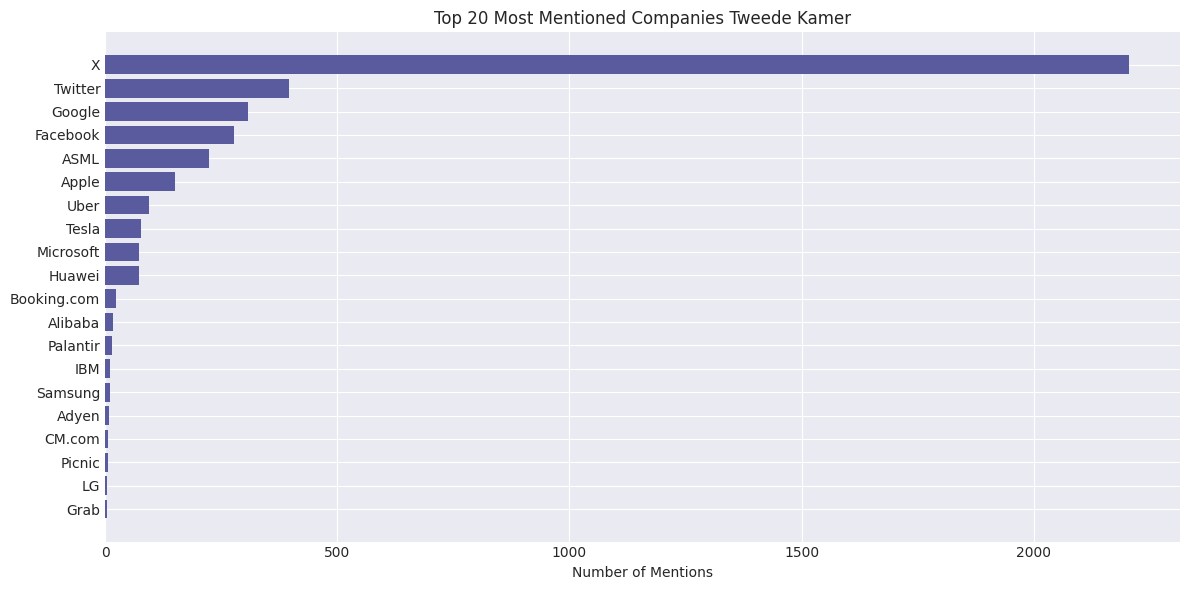

In [22]:

from collections import Counter
import matplotlib.pyplot as plt
import matplotx

# Example: df['company_hits'] contains dictionaries like {'Apple': 2, 'Google': 1, ...}

# Aggregate counts across all rows
total_counts = Counter()
for hits in tk['company_hits']:
    total_counts.update(hits)

# Convert to DataFrame for plotting
company_counts_df = pd.DataFrame(total_counts.items(), columns=['Company', 'Mentions'])
company_counts_df = company_counts_df.sort_values(by='Mentions', ascending=False)

# Plot top 20 companies
top_n = 20
plt.figure(figsize=(12,6))
plt.style.use(matplotx.styles.pacoty)
plt.barh(
    company_counts_df['Company'][:top_n][::-1],  # reverse for largest on top
    company_counts_df['Mentions'][:top_n][::-1],
)
plt.xlabel("Number of Mentions")
plt.title(f"Top {top_n} Most Mentioned Companies Tweede Kamer")
plt.tight_layout()
plt.show()


## Trends over time

In [29]:
import ast

_COMPANY_NAMES_LOWER = {name.lower() for name in _COMPANY_NAMES}

def parse_keywords(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return []

tk['keywords_parsed'] = tk['matched_keywords_all'].apply(parse_keywords)
# exclude company names so we only track AI terminology
tk['ai_keywords'] = tk['keywords_parsed'].apply(
    lambda kws: [k for k in kws if k.lower() not in _COMPANY_NAMES_LOWER]
)
tk['n_ai_keywords'] = tk['ai_keywords'].apply(len)
tk['keyword_density'] = tk['n_ai_keywords'] / tk['relevant_len_words']

tk_year = tk.dropna(subset=['year']).copy()
tk_year['year'] = tk_year['year'].astype(int)

In [42]:
import matplotlib as mpl

mpl.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.8,
    'grid.linestyle': '--',
    'axes.axisbelow': True,
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'normal',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'lines.linewidth': 2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.edgecolor': '#333333',
    'figure.dpi': 120,
})

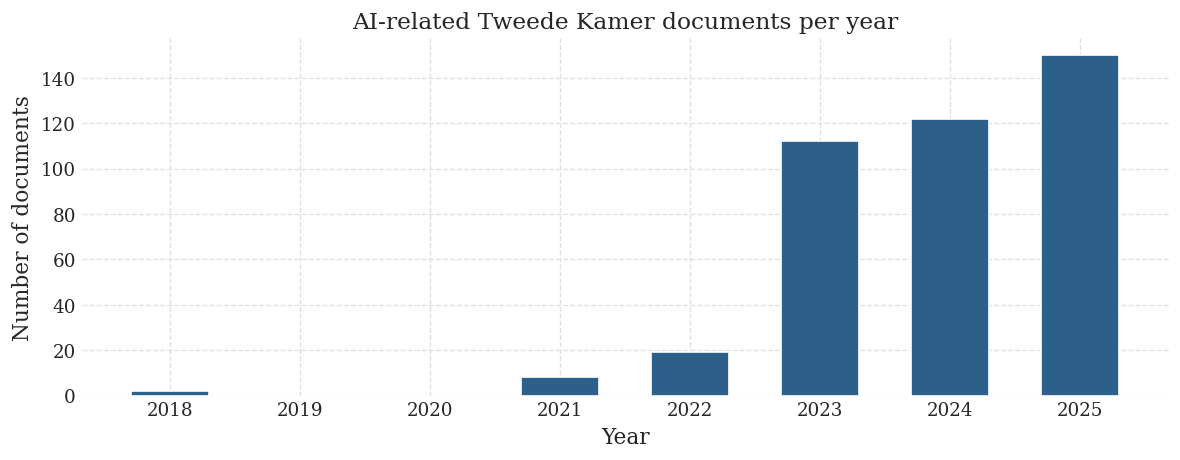

In [43]:
yearly = tk_year.groupby('year').agg(
    doc_count=('title', 'count'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(yearly['year'], yearly['doc_count'], width=0.6, color='#2c5f8a', edgecolor='white')
ax.set_ylabel('Number of documents')
ax.set_xlabel('Year')
ax.set_title('AI-related Tweede Kamer documents per year')

plt.tight_layout()
plt.show()

## Keyword frequency

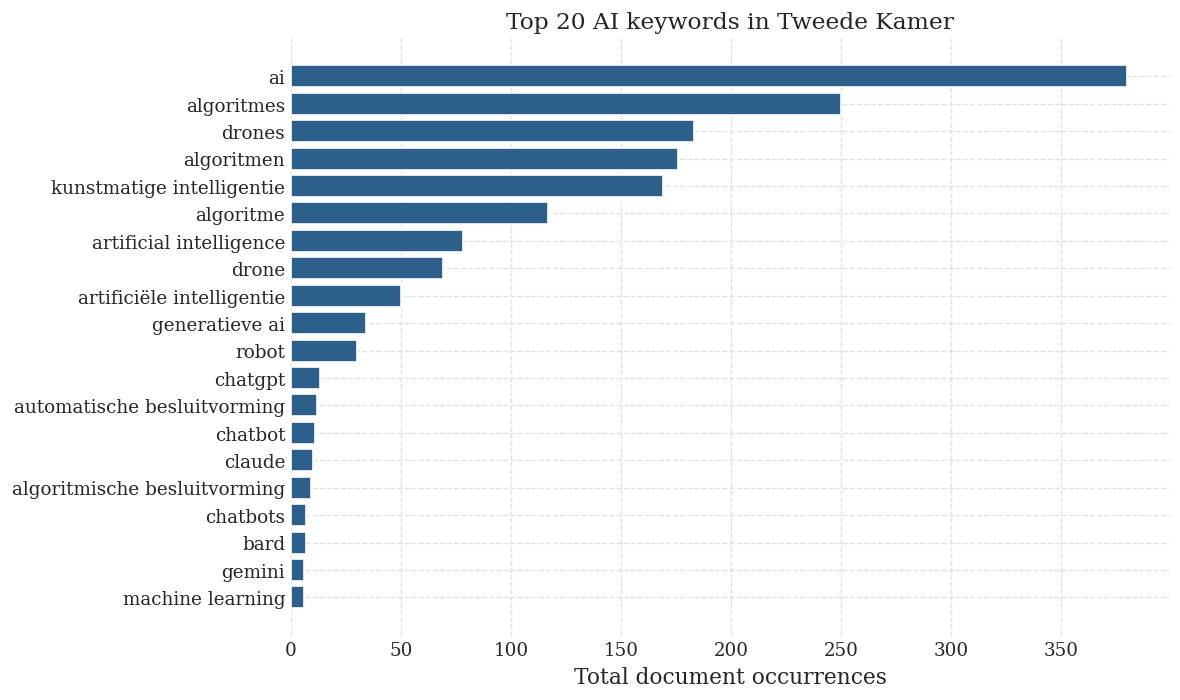

In [41]:
all_keywords = [kw for kws in tk['ai_keywords'] for kw in kws]
kw_counts = Counter(all_keywords)
kw_df = pd.DataFrame(kw_counts.items(), columns=['keyword', 'count']).sort_values('count', ascending=False)

top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(kw_df['keyword'][:top_n][::-1], kw_df['count'][:top_n][::-1], color='#2c5f8a', edgecolor='white')
plt.xlabel('Total document occurrences')
plt.title(f'Top {top_n} AI keywords in Tweede Kamer')
plt.tight_layout()
plt.show()

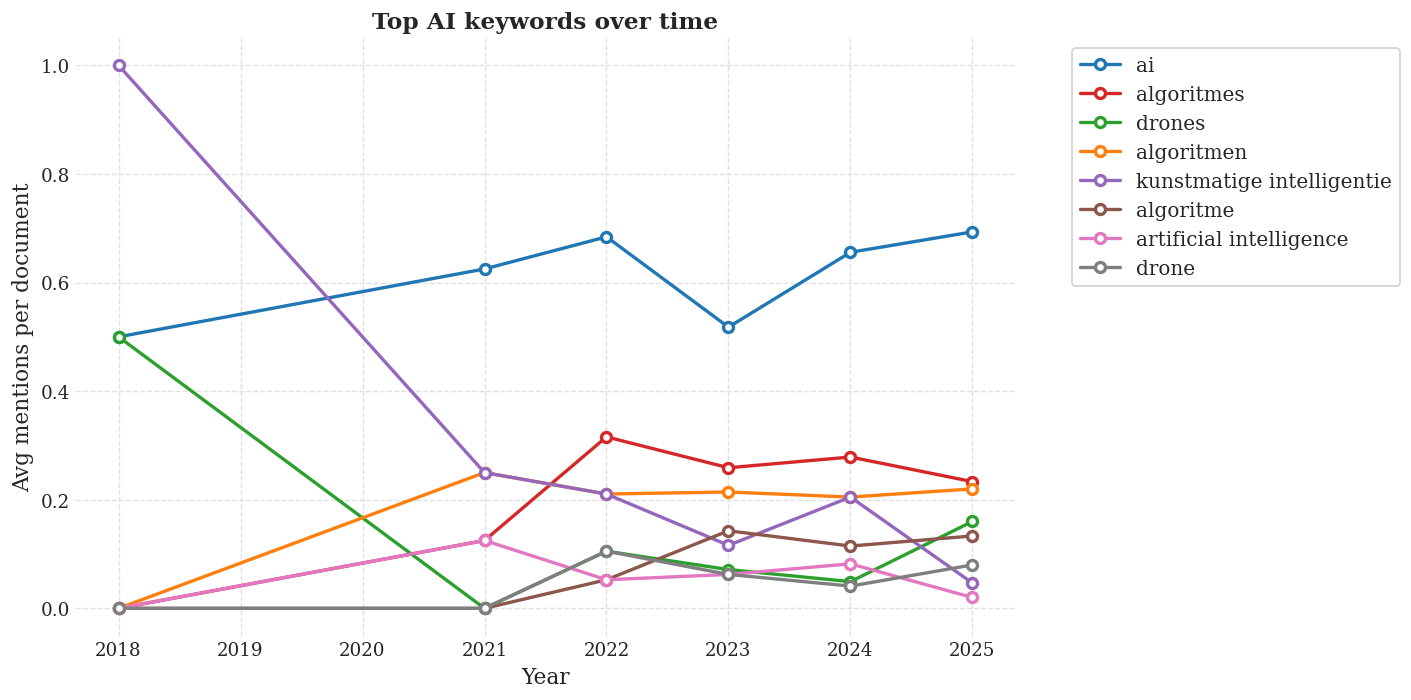

In [33]:
from collections import defaultdict

top_keywords = [k for k, _ in kw_counts.most_common(8)]

year_kw = defaultdict(Counter)
for _, row in tk_year.iterrows():
    year_kw[int(row['year'])].update(row['ai_keywords'])

years = sorted(year_kw.keys())
doc_counts_by_year = tk_year.groupby('year').size()

# colorblind-friendly palette
palette = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

plt.figure(figsize=(12, 6))
for i, kw in enumerate(top_keywords):
    vals = [year_kw[y][kw] / doc_counts_by_year[y] for y in years]
    plt.plot(years, vals, marker='o', label=kw, color=palette[i],
             markerfacecolor='white', markeredgewidth=2)

plt.xlabel('Year')
plt.ylabel('Avg mentions per document')
plt.title('Top AI keywords over time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()